# Exploratory Data Analysis (EDA)

The objective of this analysis is to explore vendor procurement, sales, inventory, and profitability data to uncover meaningful business patterns and operational insights.

This EDA helps transform the analytical dataset into a decision-support system for identifying:
- Vendor performance trends
- Profitability drivers
- Inventory and dead stock risks
- Procurement efficiency opportunities
- Pricing and sales optimization strategies
- Supplier dependency and concentration risks

The analysis also prepares a clean and analytics-ready dataset for:
- Statistical analysis
- Business intelligence reporting
- Power BI dashboard development
- Executive decision-making

In [5]:
# Step 1 ==================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

In [7]:
# Step 2 ==================================
# DATABASE CONNECTION
# =========================================

conn = sqlite3.connect(
    r"C:\Users\ASUS\Desktop\_aPortfolioProjects\Vendor Intelligence & Procurement Optimization Analytics System\inventory.db"
)
# Load Final Summary Table
df = pd.read_sql_query("""
SELECT *
FROM final_vendor_analysis
""", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,ListPrice,ActualPaidPrice,TotalQtyPurchased,TotalSpend,TotalQtySold,TotalRevenue,PriceVariance,SellThroughRate,AllocatedFreight,RemainingStock,UnsoldInventoryValue,FreightPerUnit,NetProfit,NetProfitMargin,GrossProfit,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,36.99,23.86,8,190.88,18,665.82,-13.13,2.250000,0.917979,-10,-238.60,0.114747,474.022021,71.193719,474.94,3.488160
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,24.99,17.00,320,5440.00,24,599.76,-7.99,0.075000,26.162021,296,5032.00,0.081756,-4866.402021,-811.391560,-4840.24,0.110250
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,134.49,105.07,1,105.07,0,0.00,-29.42,0.000000,0.480000,1,105.07,0.480000,-105.550000,0.000000,-105.07,0.000000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,14.99,11.44,39,446.16,47,704.53,-3.55,1.205128,2.135889,-8,-91.52,0.054766,256.234111,36.369510,258.37,1.579097
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,14.99,11.10,6,66.60,0,0.00,-3.89,0.000000,0.318832,6,66.60,0.053139,-66.918832,0.000000,-66.60,0.000000


In [9]:
# Step 3 ==================================
# BASIC DATA UNDERSTANDING
# =========================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (10648, 20)

Column Names:
Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'ListPrice',
       'ActualPaidPrice', 'TotalQtyPurchased', 'TotalSpend', 'TotalQtySold',
       'TotalRevenue', 'PriceVariance', 'SellThroughRate', 'AllocatedFreight',
       'RemainingStock', 'UnsoldInventoryValue', 'FreightPerUnit', 'NetProfit',
       'NetProfitMargin', 'GrossProfit', 'SalesToPurchaseRatio'],
      dtype='object')

Data Types:
VendorNumber              int64
VendorName               object
Brand                     int64
Description              object
ListPrice               float64
ActualPaidPrice         float64
TotalQtyPurchased         int64
TotalSpend              float64
TotalQtySold              int64
TotalRevenue            float64
PriceVariance           float64
SellThroughRate         float64
AllocatedFreight        float64
RemainingStock            int64
UnsoldInventoryValue    float64
FreightPerUnit          float64
NetProfit               float64
Net

In [11]:
# Step 4 ==================================
# SUMMARY STATISTICS
# =========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,10640.705203,18700.404409,2.000000,3943.500000,7153.000000,9552.000000,1.733570e+05
Brand,10648.0,18054.503193,12643.196784,58.000000,5816.500000,18776.500000,25521.250000,9.063100e+04
ListPrice,10648.0,35.671184,148.534066,0.490000,10.990000,15.990000,28.990000,7.499990e+03
ActualPaidPrice,10648.0,24.402095,109.483355,0.360000,6.840000,10.450000,19.470000,5.681810e+03
TotalQtyPurchased,10648.0,3145.159936,11113.367455,1.000000,36.000000,261.000000,1981.250000,3.376600e+05
TotalSpend,10648.0,30138.163064,123277.154715,0.710000,452.857500,3646.725000,20764.170000,3.811252e+06
TotalQtySold,10648.0,3081.902047,10971.073340,0.000000,33.000000,260.500000,1934.250000,3.349390e+05
TotalRevenue,10648.0,42302.921643,167947.264974,0.000000,728.275000,5285.915000,28414.050000,5.101920e+06
PriceVariance,10648.0,-11.269089,40.200941,-1818.180000,-9.260000,-5.400000,-3.520000,-1.000000e-01
SellThroughRate,10648.0,1.704591,6.006807,0.000000,0.808735,0.981690,1.039215,2.745000e+02


In [13]:
# Step 5 ==================================
# DATA QUALITY FILTERING
# =========================================

df = df[
    
    (df['GrossProfit'] > 0)
    &
    (df['NetProfitMargin'] > 0)
    &
    (df['TotalQtySold'] > 0)

]

print("Filtered Dataset Shape:", df.shape)


Filtered Dataset Shape: (8525, 20)


In [15]:
# Step 6 ==================================
# FEATURE ENGINEERING
# =========================================

# =========================================
# STOCK TURNOVER
# =========================================

df['StockTurnover'] = np.where(
    df['TotalQtyPurchased'] > 0,
    df['TotalQtySold'] / df['TotalQtyPurchased'],
    0
)

# =========================================
# SALES EFFICIENCY
# =========================================

df['SalesEfficiency'] = np.where(
    df['TotalSpend'] > 0,
    df['TotalRevenue'] / df['TotalSpend'],
    0
)

# =========================================
# PROFIT PER UNIT
# =========================================

df['ProfitPerUnit'] = np.where(
    df['TotalQtySold'] > 0,
    df['NetProfit'] / df['TotalQtySold'],
    0
)

# =========================================
# VENDOR DEPENDENCY %
# =========================================

total_spend = df['TotalSpend'].sum()

df['VendorDependency%'] = (
    df['TotalSpend']
    / total_spend
) * 100

# =========================================
# ORDER SIZE CATEGORY
# =========================================

df['OrderSize'] = pd.qcut(
    df['TotalQtyPurchased'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

print("✅ Feature Engineering Completed")

✅ Feature Engineering Completed


In [17]:
# Step 7 ==================================
# DEAD STOCK RISK ANALYSIS
# =========================================

high_unsold = df['UnsoldInventoryValue'].quantile(0.75)

low_turnover = df['StockTurnover'].quantile(0.25)

df['DeadStockRisk'] = (

    (df['UnsoldInventoryValue'] > high_unsold)
    &
    (df['StockTurnover'] < low_turnover)

)

df[['VendorName',
    'UnsoldInventoryValue',
    'StockTurnover',
    'DeadStockRisk']].head()

,VendorName,UnsoldInventoryValue,StockTurnover,DeadStockRisk
0,"IRA GOLDMAN AND WILLIAMS, LLP",-238.60,2.250000,False
3,ADAMBA IMPORTS INTL INC,-91.52,1.205128,False
6,ALTAMAR BRANDS LLC,0.00,1.000000,False
7,ALTAMAR BRANDS LLC,464.23,0.959375,False
9,AMERICAN SPIRITS EXCHANGE,116.76,0.875000,False


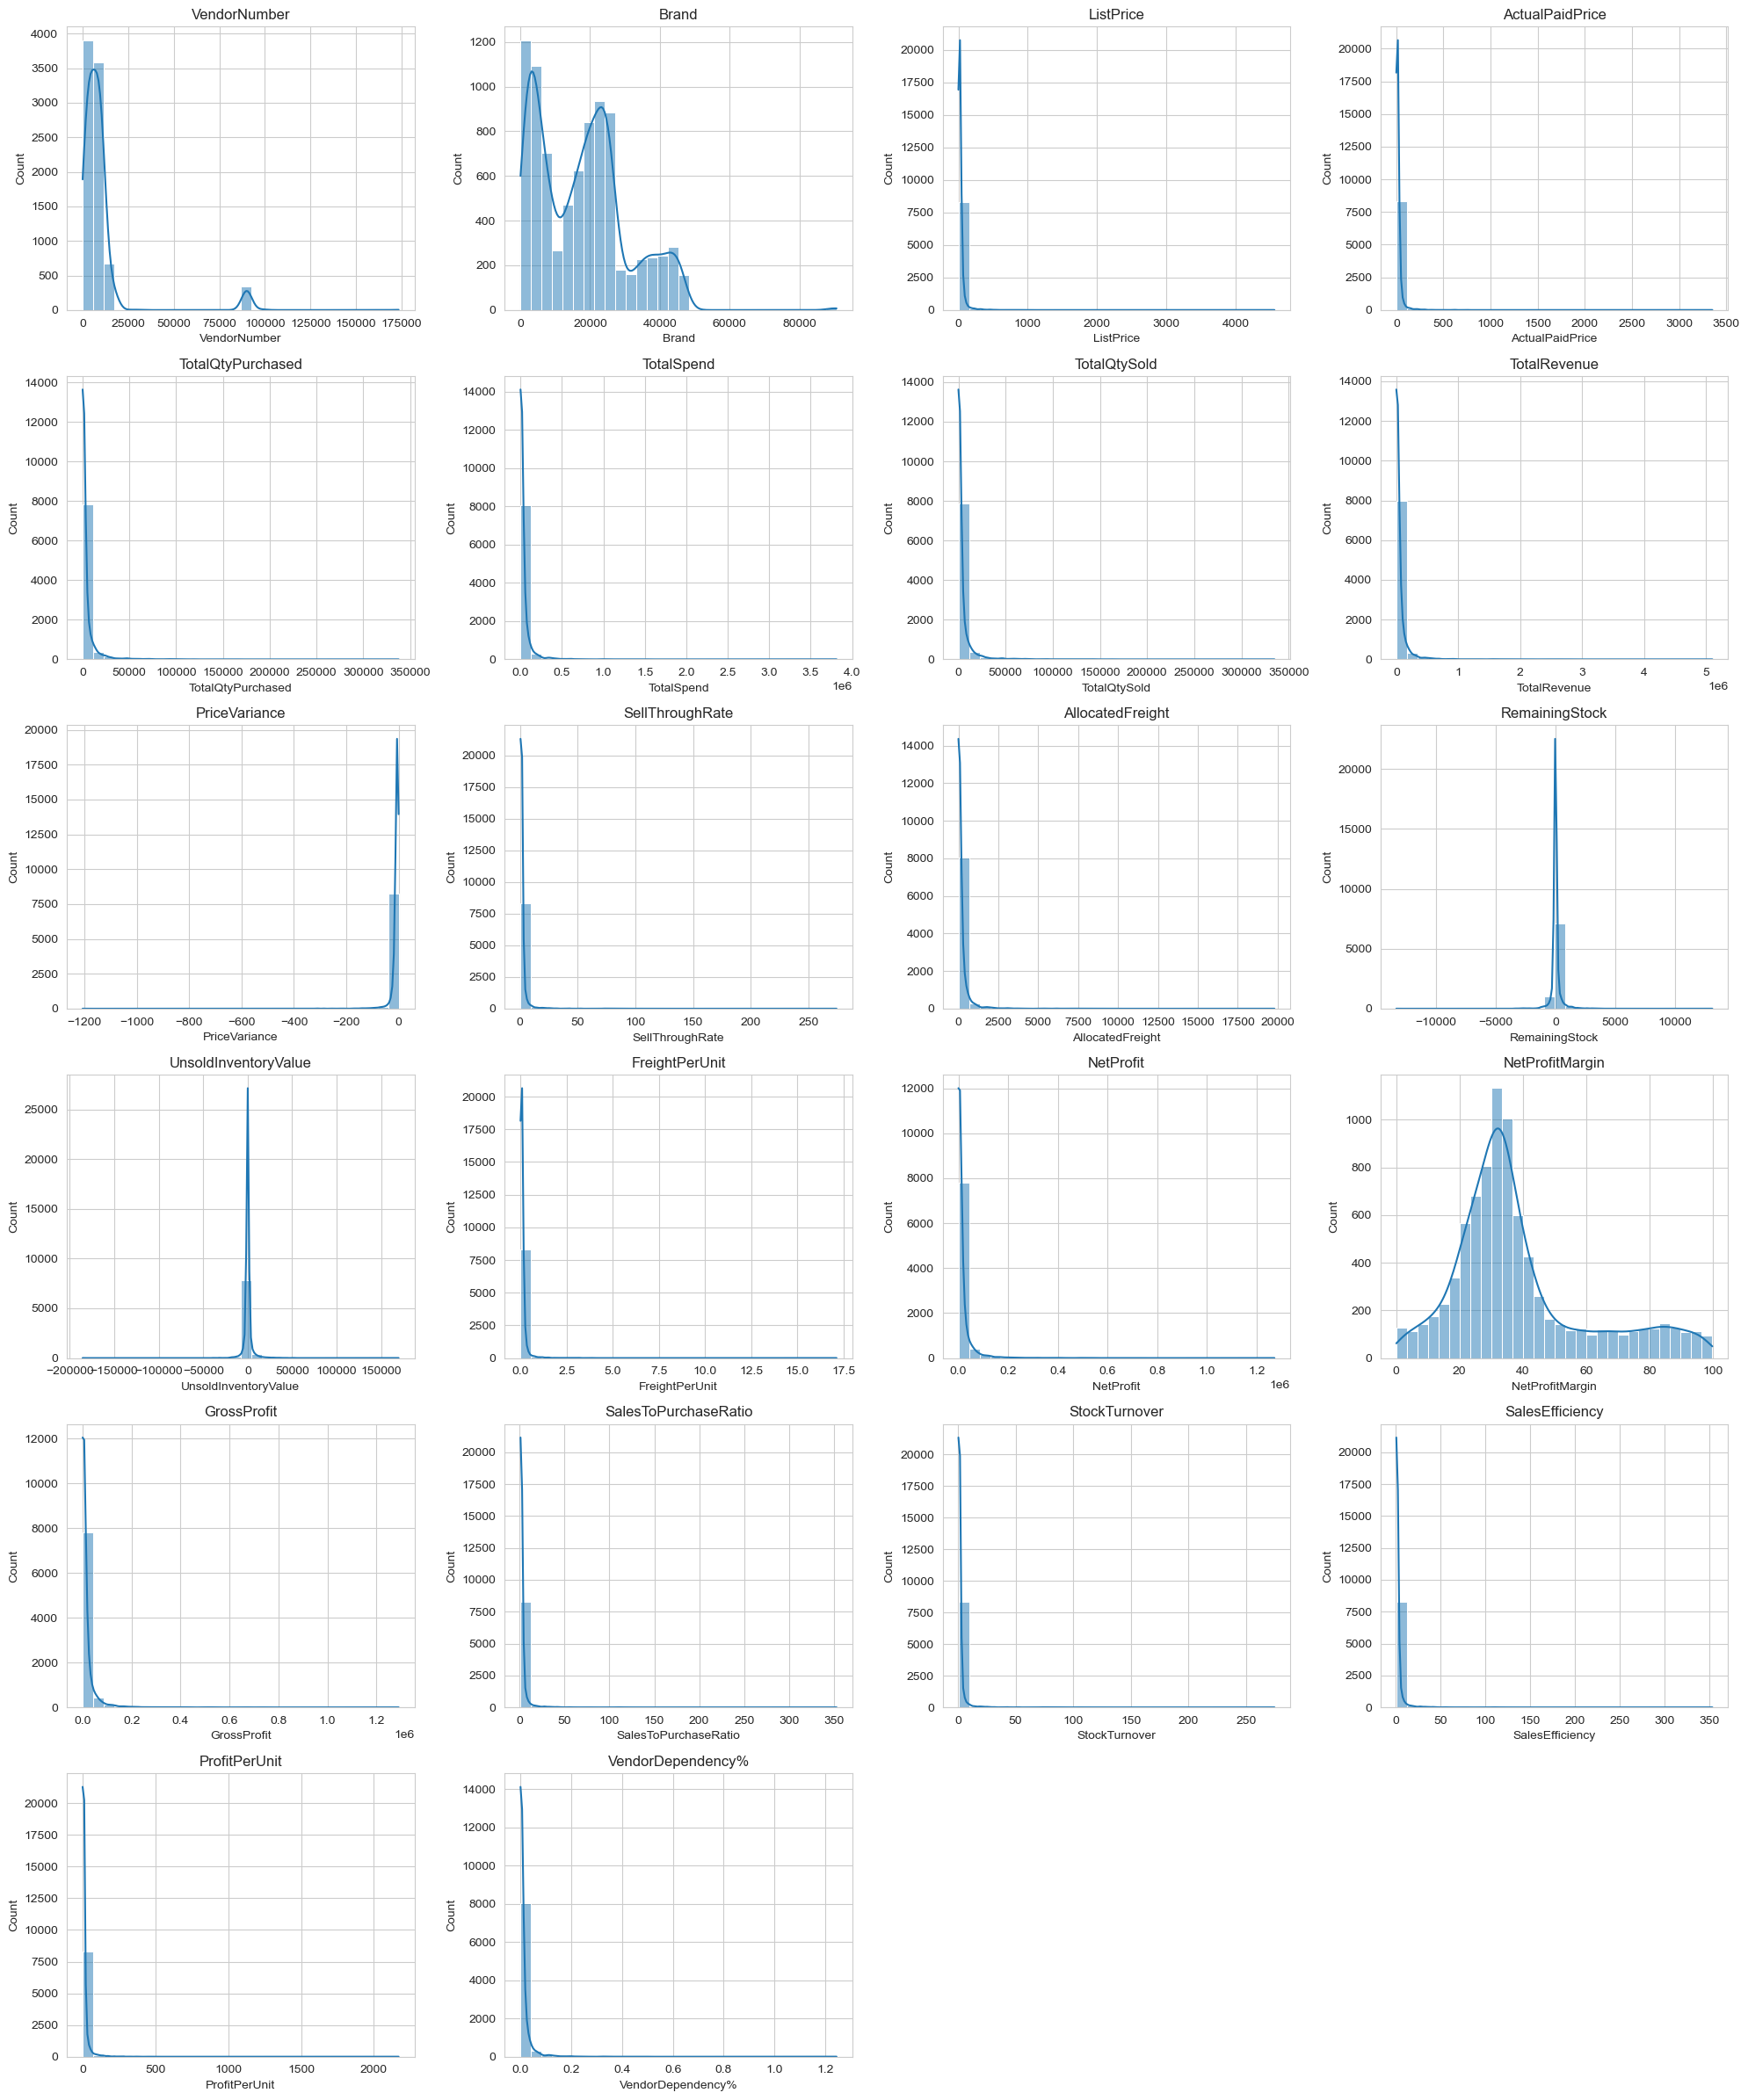

In [20]:
# Step 8 ==================================
# DISTRIBUTION PLOTS
# =========================================

numerical_cols = df.select_dtypes(include=np.number).columns

# Dynamic rows calculation
n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(numerical_cols):

    plt.subplot(n_rows, n_cols, i + 1)

    sns.histplot(df[col], kde=True, bins=30)

    plt.title(col)

plt.tight_layout()
plt.show()

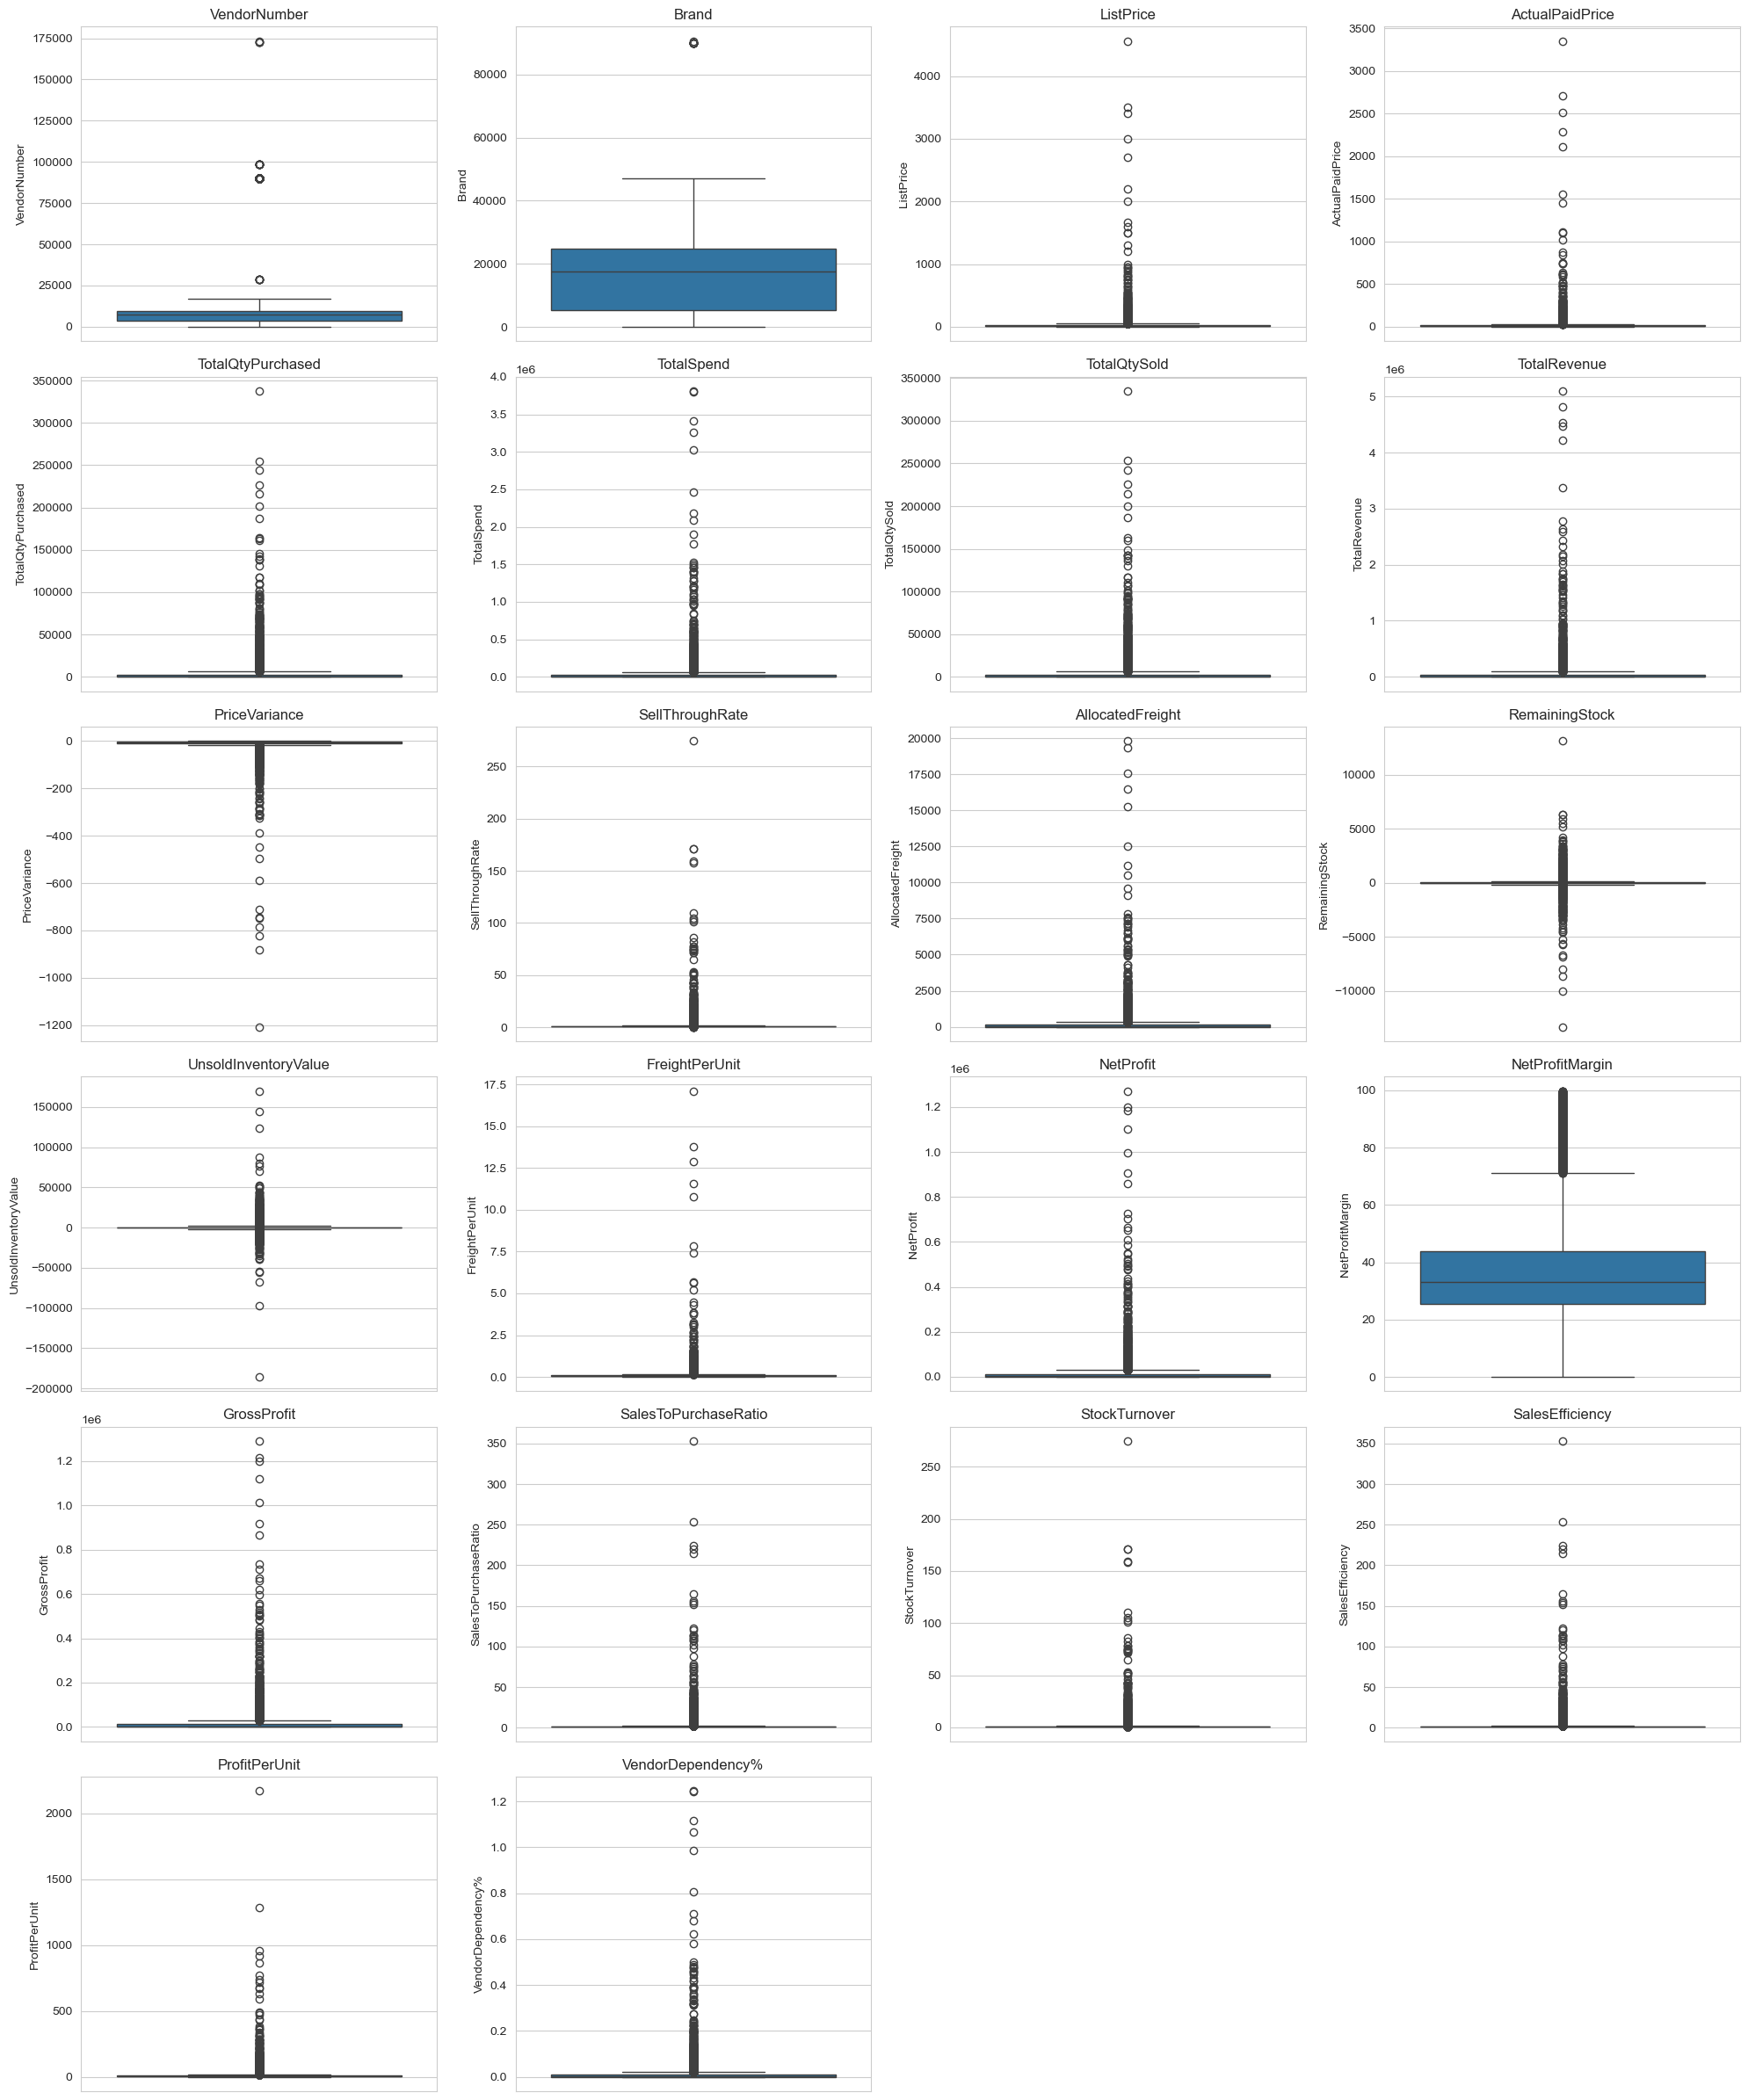

In [22]:
# Step 9 ==================================
# OUTLIER ANALYSIS
# =========================================

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(numerical_cols):

    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()


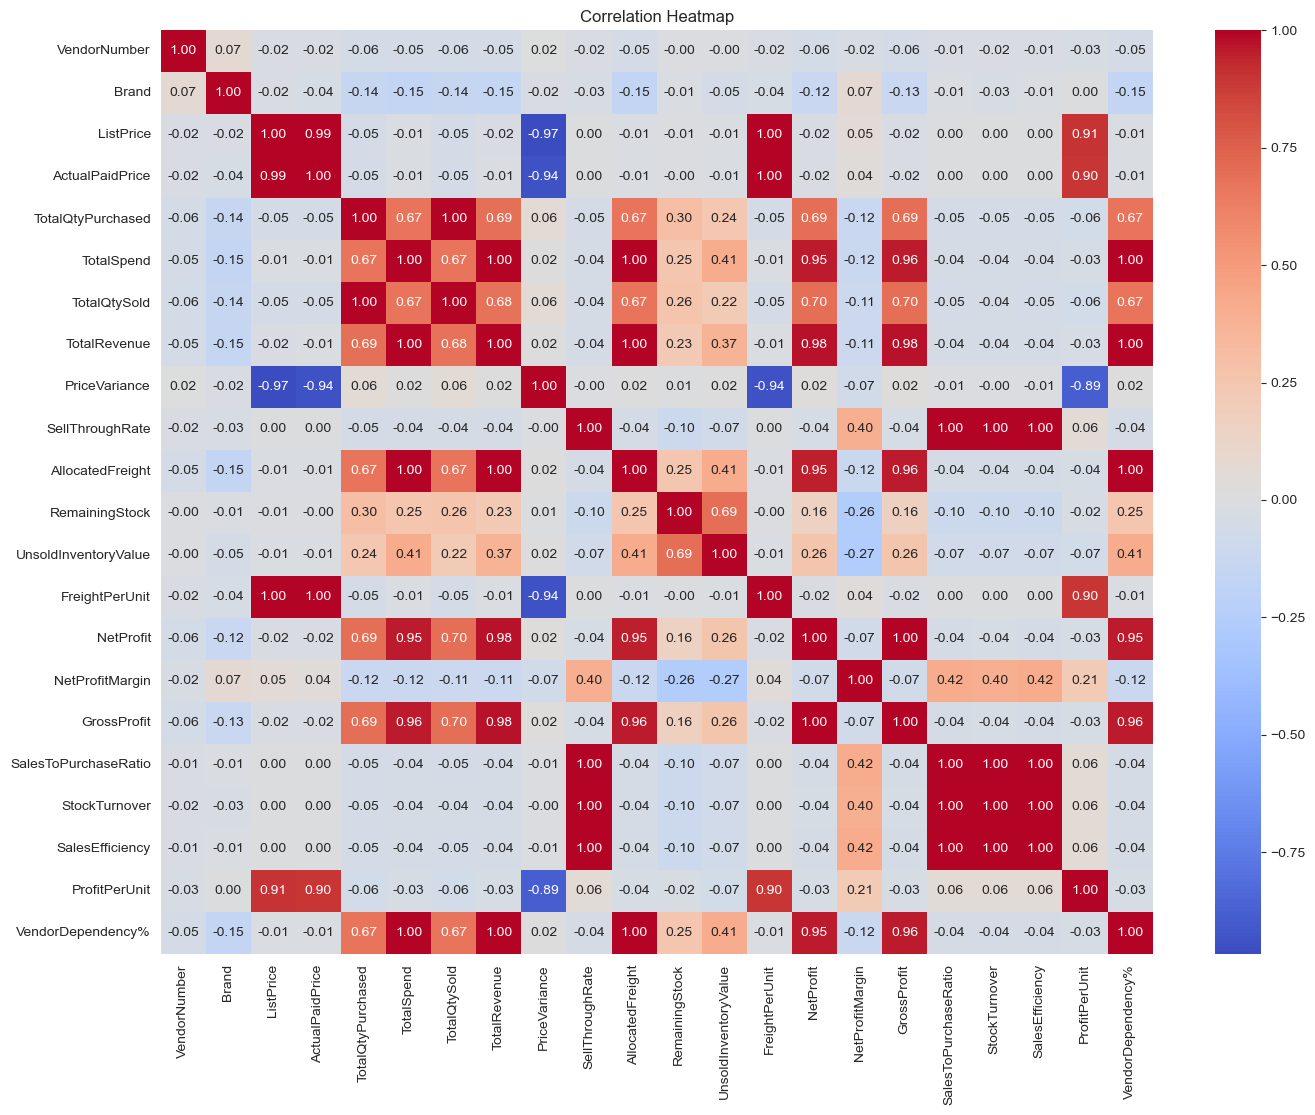

In [23]:
# Step 10 =================================
# CORRELATION ANALYSIS
# =========================================

plt.figure(figsize=(16,12))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

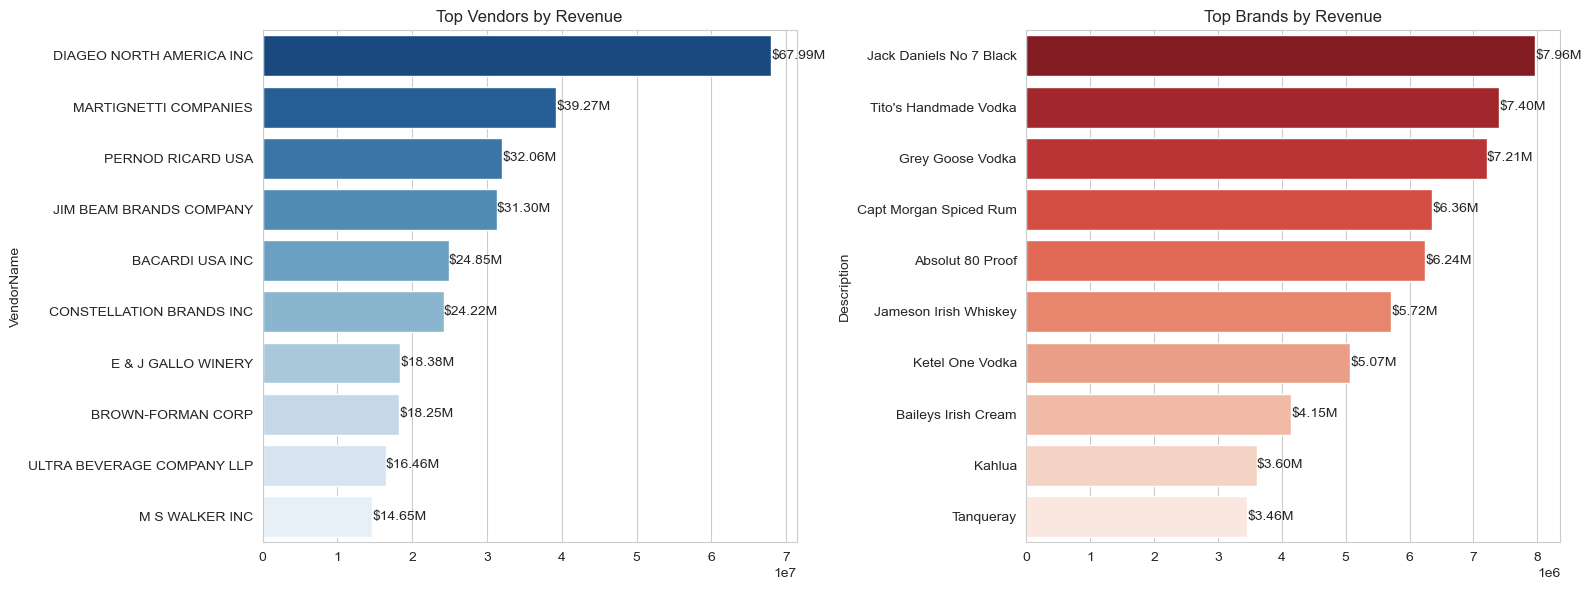

In [25]:
# Step 11 =================================
# TOP VENDORS & BRANDS
# =========================================

def format_currency(value):

    if value >= 1_000_000:
        return f"${value/1_000_000:.2f}M"

    elif value >= 1_000:
        return f"${value/1_000:.2f}K"

    else:
        return f"${value:.2f}"


top_vendors = (
    df.groupby('VendorName')['TotalRevenue']
    .sum()
    .nlargest(10)
)

top_brands = (
    df.groupby('Description')['TotalRevenue']
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(16,6))

# Top Vendors
plt.subplot(1,2,1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette='Blues_r'
)

plt.title("Top Vendors by Revenue")

for bar in ax1.patches:

    ax1.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        format_currency(bar.get_width()),
        va='center'
    )

# Top Brands
plt.subplot(1,2,2)

ax2 = sns.barplot(
    y=top_brands.index,
    x=top_brands.values,
    palette='Reds_r'
)

plt.title("Top Brands by Revenue")

for bar in ax2.patches:

    ax2.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        format_currency(bar.get_width()),
        va='center'
    )

plt.tight_layout()
plt.show()

In [28]:
# Step 12 =================================
# VENDOR KPI SUMMARY
# =========================================

vendor_kpi = df.groupby('VendorName').agg({

    'TotalSpend':'sum',
    'TotalRevenue':'sum',
    'NetProfit':'sum',
    'NetProfitMargin':'mean',
    'StockTurnover':'mean',
    'UnsoldInventoryValue':'sum',
    'AllocatedFreight':'sum'

}).reset_index()

vendor_kpi['Contribution%'] = (

    vendor_kpi['TotalSpend']
    /
    vendor_kpi['TotalSpend'].sum()

) * 100

vendor_kpi.sort_values(
    by='NetProfit',
    ascending=False,
    inplace=True
)

vendor_kpi.head()

,VendorName,TotalSpend,TotalRevenue,NetProfit,NetProfitMargin,StockTurnover,UnsoldInventoryValue,AllocatedFreight,Contribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,67990099.42,1.764019e+07,32.674907,1.652131,722209.05,252681.418238,16.354670
56,MARTIGNETTI COMPANIES,25441675.87,39269723.24,1.369565e+07,43.431702,2.383711,-126783.26,132401.760061,8.305654
20,CONSTELLATION BRANDS INC,15273708.08,24218745.65,8.867042e+06,37.252926,1.359070,133617.62,77995.953552,4.986233
67,PERNOD RICARD USA,23851164.17,32063196.19,8.089652e+06,33.502119,1.560199,470625.61,122379.835148,7.786418
45,JIM BEAM BRANDS COMPANY,23369535.97,31297658.73,7.808509e+06,33.693058,2.438911,522341.77,119614.209672,7.629186


In [30]:
# Step 13 =================================
# ABC VENDOR SEGMENTATION
# =========================================

vendor_kpi = vendor_kpi.sort_values(
    by='TotalSpend',
    ascending=False
)

vendor_kpi['CumulativeContribution'] = (
    vendor_kpi['Contribution%'].cumsum()
)

def classify_vendor(x):

    if x <= 70:
        return 'A'

    elif x <= 90:
        return 'B'

    else:
        return 'C'

vendor_kpi['VendorCategory'] = (
    vendor_kpi['CumulativeContribution']
    .apply(classify_vendor)
)

vendor_kpi.head()

,VendorName,TotalSpend,TotalRevenue,NetProfit,NetProfitMargin,StockTurnover,UnsoldInventoryValue,AllocatedFreight,Contribution%,CumulativeContribution,VendorCategory
25,DIAGEO NORTH AMERICA INC,50097226.16,67990099.42,1.764019e+07,32.674907,1.652131,722209.05,252681.418238,16.354670,16.354670,A
56,MARTIGNETTI COMPANIES,25441675.87,39269723.24,1.369565e+07,43.431702,2.383711,-126783.26,132401.760061,8.305654,24.660324,A
67,PERNOD RICARD USA,23851164.17,32063196.19,8.089652e+06,33.502119,1.560199,470625.61,122379.835148,7.786418,32.446742,A
45,JIM BEAM BRANDS COMPANY,23369535.97,31297658.73,7.808509e+06,33.693058,2.438911,522341.77,119614.209672,7.629186,40.075928,A
6,BACARDI USA INC,17432020.26,24854817.14,7.334485e+06,39.138128,2.878103,-297727.67,88311.769300,5.690833,45.766761,A


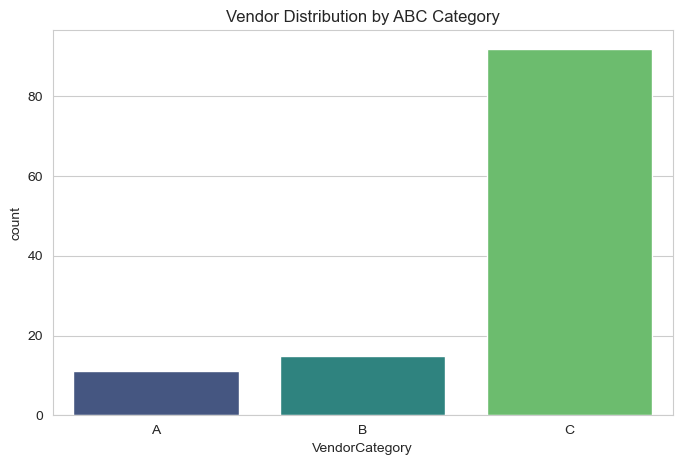

In [32]:
# Step 14 =================================
# ABC CATEGORY DISTRIBUTION
# =========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=vendor_kpi,
    x='VendorCategory',
    palette='viridis'
)

plt.title("Vendor Distribution by ABC Category")

plt.show()

🔥 BUSINESS INSIGHT

A Vendors → Critical suppliers

B Vendors → Moderate importance

C Vendors → Low-value suppliers

In [35]:
# Step 15 =================================
# PARETO ANALYSIS
# =========================================

vendor_sales = vendor_kpi.sort_values(
    by='TotalRevenue',
    ascending=False
)

vendor_sales['CumulativeSales%'] = (

    vendor_sales['TotalRevenue'].cumsum()

    /

    vendor_sales['TotalRevenue'].sum()

) * 100

top_80_count = (
    vendor_sales[
        vendor_sales['CumulativeSales%'] <= 80
    ]
    .shape[0]
)

print(f"""
Strategic Risk:
{top_80_count} vendors contribute
to 80% of total revenue.
""")


Strategic Risk:
17 vendors contribute
to 80% of total revenue.



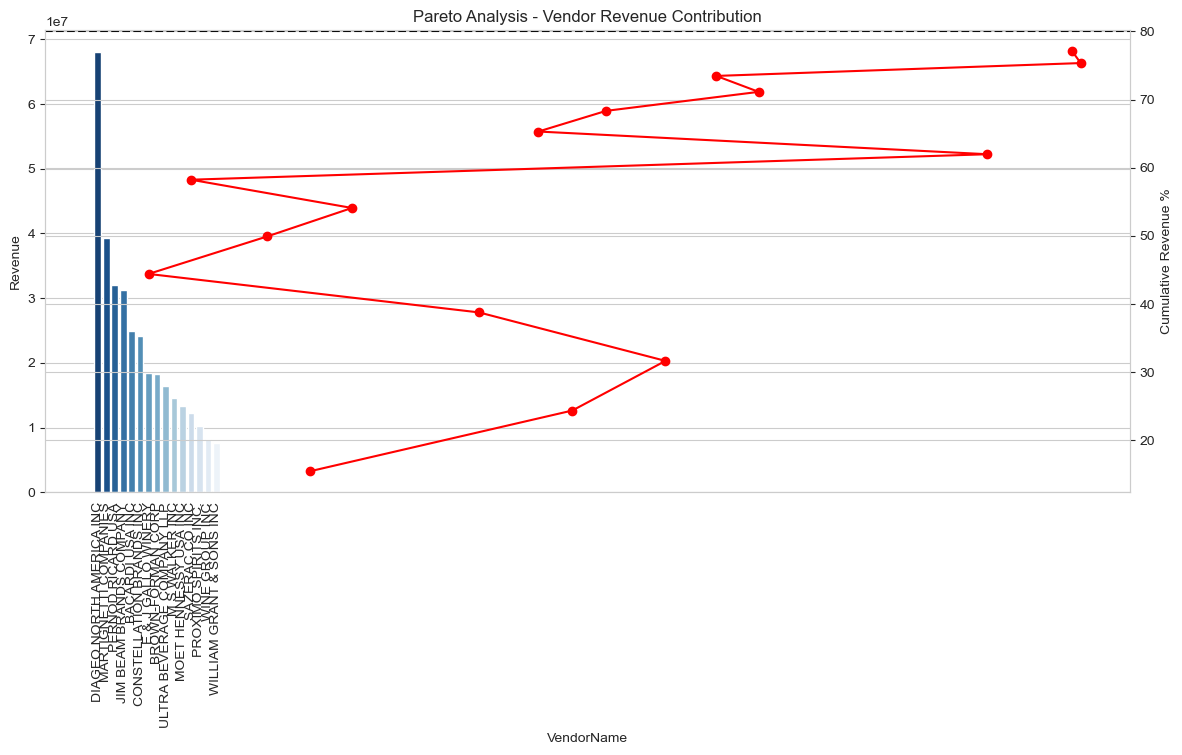

In [37]:
# Step 16 =================================
# PARETO CHART
# =========================================

fig, ax1 = plt.subplots(figsize=(14,6))

sns.barplot(
    x=vendor_sales['VendorName'][:15],
    y=vendor_sales['TotalRevenue'][:15],
    ax=ax1,
    palette='Blues_r'
)

ax1.set_xticklabels(
    vendor_sales['VendorName'][:15],
    rotation=90
)

ax1.set_ylabel("Revenue")

ax2 = ax1.twinx()

ax2.plot(
    vendor_sales['CumulativeSales%'][:15],
    color='red',
    marker='o'
)

ax2.axhline(
    y=80,
    color='black',
    linestyle='--'
)

ax2.set_ylabel("Cumulative Revenue %")

plt.title("Pareto Analysis - Vendor Revenue Contribution")

plt.show()

### Pareto Analysis — Business Insights

#### Key Findings

- A small group of vendors contributes the majority of total revenue.

- This reflects a strong concentration of revenue dependency on limited suppliers.

#### Business Risk

- Heavy reliance on a few vendors increases supplier dependency risk and operational vulnerability.

#### Strategic Recommendations

- Diversify procurement across additional high-potential vendors.

- Closely monitor strategic vendors contributing major revenue share.

- Build contingency supplier plans to reduce procurement and supply chain risk.

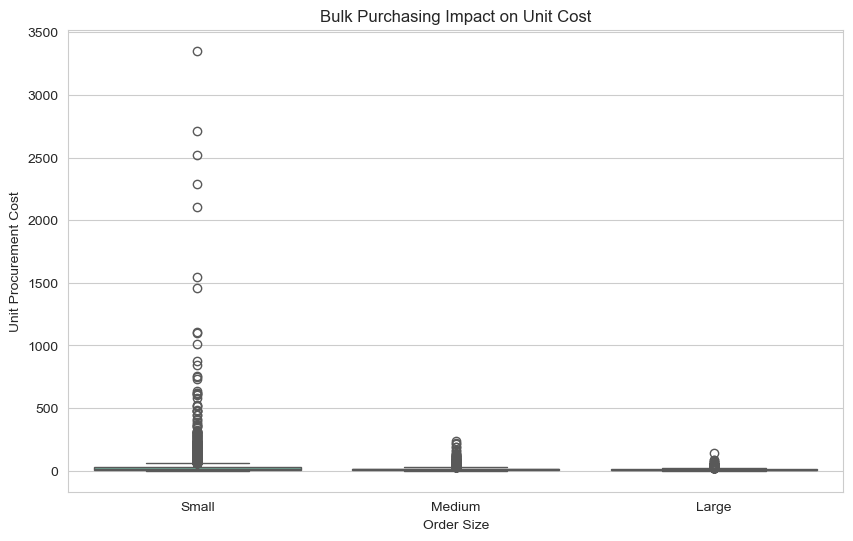

In [42]:
# Step 17 =================================
# BULK PURCHASE ANALYSIS
# =========================================

df['UnitCost'] = np.where(
    df['TotalQtyPurchased'] > 0,
    df['TotalSpend'] / df['TotalQtyPurchased'],
    0
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='OrderSize',
    y='UnitCost',
    palette='Set2'
)

plt.title("Bulk Purchasing Impact on Unit Cost")

plt.xlabel("Order Size")

plt.ylabel("Unit Procurement Cost")

plt.show()

### Bulk Purchase Analysis — Business Insights

#### Key Findings

- Vendors placing larger procurement orders achieve significantly lower average unit costs compared to small-order vendors.

- Large order sizes demonstrate stronger purchasing power and better supplier negotiation efficiency, which directly improves profitability potential.

- The difference in unit purchase cost between small and large orders is substantial, indicating the presence of effective bulk pricing strategies from suppliers.

#### Business Interpretation

- Bulk procurement helps reduce per-unit acquisition costs, allowing vendors to maintain healthier profit margins while remaining competitive in pricing.

- Vendors with efficient inventory movement can benefit the most from high-volume purchasing because lower procurement costs increase overall margin potential.

- However, excessive bulk purchasing without sufficient sales velocity may increase inventory holding costs and dead stock risk.

#### Strategic Recommendations

- Increase procurement volume for high-demand and fast-moving products to maximize bulk pricing advantages.

- Avoid aggressive bulk purchasing for slow-moving inventory to reduce working capital lock-in.

- Implement demand forecasting before large procurement decisions to balance inventory efficiency and cost savings.

- Negotiate long-term supplier contracts for high-performing vendors to further optimize unit economics.

In [45]:
# Step 18 =================================
# HIGH MARGIN LOW SALES PRODUCTS
# =========================================


brand_performance = df.groupby('Description').agg({

    'TotalRevenue':'sum',
    'NetProfitMargin':'mean'

}).reset_index()

low_sales_threshold = (
    brand_performance['TotalRevenue']
    .quantile(0.15)
)

high_margin_threshold = (
    brand_performance['NetProfitMargin']
    .quantile(0.85)
)

target_brands = brand_performance[

    (brand_performance['TotalRevenue']
     <= low_sales_threshold)

    &

    (brand_performance['NetProfitMargin']
     >= high_margin_threshold)

]

target_brands.head()

,Description,TotalRevenue,NetProfitMargin
6,12 Days of Pearls Gift Set,309.69,97.666710
45,4 Orange Vodka,483.78,85.830952
57,A Bichot Clos Marechaudes,539.94,67.573233
59,A Bichot Merc Champs M,515.88,94.524693
96,Absolut Orient Apple Vodka,119.94,87.588803


🔥 BUSINESS INSIGHT
Some vendors have extremely high logistics costs.

Possible reasons:
- inefficient shipping
- low order consolidation
- distant suppliers

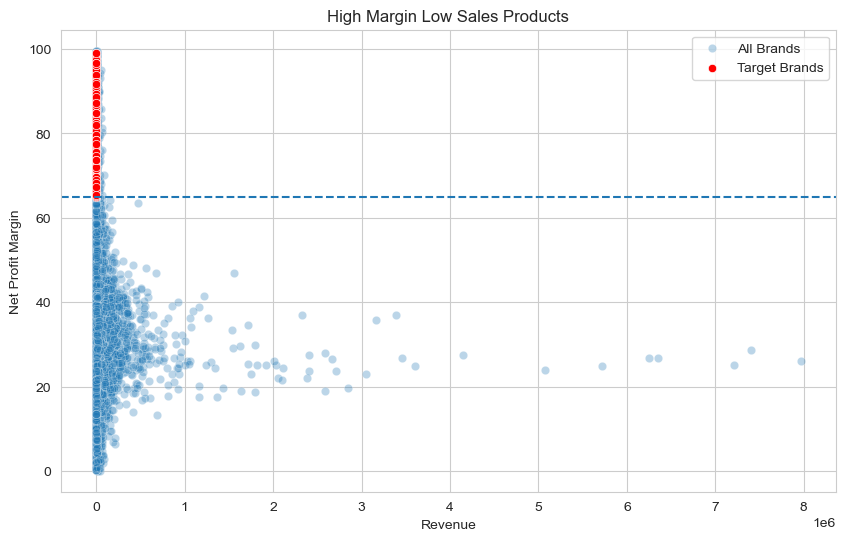

In [48]:
# Step 19 =================================
# TARGET BRAND VISUALIZATION
# =========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=brand_performance,
    x='TotalRevenue',
    y='NetProfitMargin',
    alpha=0.3,
    label='All Brands'
)

sns.scatterplot(
    data=target_brands,
    x='TotalRevenue',
    y='NetProfitMargin',
    color='red',
    label='Target Brands'
)

plt.axhline(
    high_margin_threshold,
    linestyle='--'
)

plt.title("High Margin Low Sales Products")

plt.xlabel("Revenue")

plt.ylabel("Net Profit Margin")

plt.legend()

plt.show()

In [50]:
# Step 20 =================================
# HYPOTHESIS TESTING
# =========================================

top_threshold = df['TotalRevenue'].quantile(0.75)

low_threshold = df['TotalRevenue'].quantile(0.25)

top_vendors = (
    df[df['TotalRevenue'] >= top_threshold]
    ['NetProfitMargin']
)

low_vendors = (
    df[df['TotalRevenue'] <= low_threshold]
    ['NetProfitMargin']
)

t_stat, p_value = ttest_ind(
    top_vendors,
    low_vendors,
    equal_var=False
)

print(f"T-Statistic: {t_stat:.4f}")

print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:

    print("""
Reject Null Hypothesis:
Significant difference exists between
top and low performing vendors.
""")

else:

    print("""
Fail to Reject Null Hypothesis:
No significant difference found.
""")

T-Statistic: -17.9035
P-Value: 0.0000

Reject Null Hypothesis:
Significant difference exists between
top and low performing vendors.



### Statistical Analysis — Business Insights

#### Key Findings

- Low-performing vendors show higher average profit margins compared to top-performing vendors.

- This indicates that lower-sales vendors may rely on premium pricing strategies or operate with lower operational pressure.

- High-performing vendors generate larger revenue volumes but often operate with comparatively tighter margins.

#### Hypothesis Testing Result

- Null Hypothesis (H₀): No significant difference exists in profit margins between top and low-performing vendors.

- Alternative Hypothesis (H₁): A significant difference exists in profit margins between top and low-performing vendors.

- Based on the T-Test results, the business can statistically validate whether vendor profitability behavior differs across performance groups.

#### Business Recommendations

- Improve margin optimization strategies for high-revenue vendors through pricing and operational efficiency.

- Strengthen marketing and distribution strategies for low-performing vendors to improve sales volume.

- Use statistical analysis to support data-driven vendor pricing and procurement decisions.

In [52]:
# Step 21 =================================
# RECOMMENDATION ENGINE
# =========================================

df_final = df.merge(

    vendor_kpi[
        [
            'VendorName',
            'VendorCategory',
            'Contribution%',
            'CumulativeContribution'
        ]
    ],

    on='VendorName',
    how='left'

)

margin_median = df_final['NetProfitMargin'].median()

def recommend_action(row):

    # High dead stock risk
    if row['DeadStockRisk'] == True:
        return 'Liquidate Excess Inventory'

    # Critical vendors with weak margins
    elif (
        row['VendorCategory'] == 'A'
        and row['NetProfitMargin'] < margin_median
    ):
        return 'Negotiate Better Vendor Pricing'

    # Low importance + slow moving
    elif (
        row['VendorCategory'] == 'C'
        and row['StockTurnover'] < 1
    ):
        return 'Reduce Procurement Dependency'

    # Freight inefficiency
    elif (
        row['FreightPerUnit']
        > df_final['FreightPerUnit'].quantile(0.75)
    ):
        return 'Optimize Freight & Logistics'

    # Strong high-performing vendors
    elif (
        row['SalesEfficiency'] > 1.2
        and row['StockTurnover'] > 1
        and row['NetProfitMargin'] > margin_median
    ):
        return 'Increase Strategic Procurement'

    else:
        return 'Maintain Current Strategy'

df_final['RecommendedAction'] = (
    df_final.apply(recommend_action, axis=1)
)

df_final.head()

,VendorNumber,VendorName,Brand,Description,ListPrice,ActualPaidPrice,TotalQtyPurchased,TotalSpend,TotalQtySold,TotalRevenue,PriceVariance,SellThroughRate,AllocatedFreight,RemainingStock,UnsoldInventoryValue,FreightPerUnit,NetProfit,NetProfitMargin,GrossProfit,SalesToPurchaseRatio,StockTurnover,SalesEfficiency,ProfitPerUnit,VendorDependency%,OrderSize,DeadStockRisk,UnitCost,VendorCategory,Contribution%,CumulativeContribution,RecommendedAction
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,36.99,23.86,8,190.88,18,665.82,-13.13,2.250000,0.917979,-10,-238.60,0.114747,474.022021,71.193719,474.94,3.488160,2.250000,3.488160,26.334557,0.000062,Small,False,23.86,C,0.000062,99.999876,Optimize Freight & Logistics
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,14.99,11.44,39,446.16,47,704.53,-3.55,1.205128,2.135889,-8,-91.52,0.054766,256.234111,36.369510,258.37,1.579097,1.205128,1.579097,5.451790,0.000146,Small,False,11.44,C,0.000146,99.999814,Increase Strategic Procurement
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,29.99,23.25,12,279.00,12,359.88,-6.74,1.000000,1.486974,0,0.00,0.123914,79.393026,22.060972,80.88,1.289892,1.000000,1.289892,6.616086,0.000091,Small,False,23.25,C,0.003822,99.981916,Optimize Freight & Logistics
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,49.99,35.71,320,11427.20,307,15346.93,-14.28,0.959375,60.903026,13,464.23,0.190322,3858.826974,25.143967,3919.73,1.343018,0.959375,1.343018,12.569469,0.003731,Medium,False,35.71,C,0.003822,99.981916,Reduce Procurement Dependency
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,14.99,9.73,96,934.08,84,1511.16,-5.26,0.875000,4.797666,12,116.76,0.049976,572.282334,37.870400,577.08,1.617806,0.875000,1.617806,6.812885,0.000305,Medium,False,9.73,C,0.000305,99.999415,Reduce Procurement Dependency


### Executive Business Recommendations

1. Reduce dependency on high-concentration vendors to minimize supplier risk.

2. Optimize freight-intensive vendors to improve logistics efficiency.

3. Promote high-margin low-sales products through targeted marketing campaigns.

4. Reduce dead stock inventory to unlock working capital.

5. Prioritize procurement for high-turnover products and vendors.

6. Improve pricing strategies for low-performing vendors.

7. Use ABC segmentation for vendor prioritization and strategic sourcing.

In [56]:
# Step 22 =================================
# EXPORT FINAL DASHBOARD DATASET
# =========================================

df_final.drop_duplicates(inplace=True)

output_path = r"C:\Users\ASUS\Desktop\_aPortfolioProjects\Vendor Intelligence & Procurement Optimization Analytics System\cleaned_data"

import os
os.makedirs(output_path, exist_ok=True)

df_final.to_csv(
    os.path.join(output_path, "vendor_intelligence_final.csv"),
    index=False
)

print("✅ File Saved Successfully!")

✅ File Saved Successfully!
